# Recursive forecasting: how far can the model trust itself?

Every other notebook in this project asks the model to look at 2 hours of history and predict one value, 60 minutes ahead, in a single shot. That's the paper's own setup, and it's a reasonable thing to ask a model to do -- but it also means the model never has to live with its own mistakes. This notebook asks a different question: what happens if the model has to keep predicting forward, using its own earlier predictions as if they were real data, instead of always getting a fresh window of ground truth?

## Why this needs a different model, not just a different question

The existing models take 6 inputs per timestep (glucose, background insulin, meal insulin, carbs, a glucose moving average, and a hypo/normal/hyper label) and output exactly one thing: glucose, 60 minutes later. To run recursively -- feed a prediction back in as input for the next prediction -- the model has to predict *all* the things it needs as input, not just glucose, or it has no way to keep going without secretly relying on real future data it wouldn't actually have.

Two of those 6 inputs (the moving average, the hypo/normal/hyper label) are just simple calculations on top of the glucose history, so they don't need their own model. The other four -- glucose, background insulin, meal insulin, carbs -- all need to be predicted directly. This notebook trains one small model to do exactly that: given the last 2 hours, predict all four, 5 minutes ahead. Then it's run recursively: predict one step, treat that prediction as real, predict the next step from it, and so on.

Worth flagging up front: background insulin changes slowly and predictably, but meal insulin and carbs are the opposite -- a person eats or doses at a handful of specific moments and does nothing the rest of the time. A model trained to minimize average error on that kind of sparse, spiky data will likely learn to predict something close to zero most of the time, since that's usually the safest guess. Whether that actually happens, and what it does to the recursive glucose forecast, is checked directly below rather than assumed.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from azt1d import loading, plotting
from azt1d import reference as ref
from azt1d.glimmer import features as feat
from azt1d.glimmer import sequences as seq
from azt1d.glimmer import recursive as rec

plotting.apply_style()
pd.set_option("display.max_columns", None)

## 1. Load data, pick one patient

In [2]:
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

df = loading.load_real_dataset(RAW_DIR, PROCESSED_DIR)
SUBJECT_ID = 1  # the same illustrative patient used throughout this project
df_subject = df[df["subject_id"] == SUBJECT_ID].reset_index(drop=True)
print(f"Subject {SUBJECT_ID}: {len(df_subject):,} readings.")

Subject 1: 10,881 readings.


## 2. Train the multi-output, next-step model

In [3]:
data = rec.prepare_multi_output_data(df_subject)
print(f"train/val/test windows: {len(data.X_train)}/{len(data.X_val)}/{len(data.X_test)}")
print("Target columns:", rec.TARGET_COLUMNS)
print("Target means (train set):", dict(zip(rec.TARGET_COLUMNS, data.target_means.round(3))))
print("Target stds (train set):", dict(zip(rec.TARGET_COLUMNS, data.target_stds.round(3))))

train/val/test windows: 6949/1737/2171
Target columns: ['CGM', 'Basal', 'TotalBolusInsulinDelivered', 'CarbSize']
Target means (train set): {'CGM': np.float32(140.897), 'Basal': np.float32(1.98), 'TotalBolusInsulinDelivered': np.float32(0.493), 'CarbSize': np.float32(0.601)}
Target stds (train set): {'CGM': np.float32(37.116), 'Basal': np.float32(0.536), 'TotalBolusInsulinDelivered': np.float32(2.527), 'CarbSize': np.float32(4.756)}


In [4]:
result = rec.train_multi_output_model(data, architecture="cnn_lstm")
print(f"Trained. {result.n_params:,} parameters.")
print("Per-target validation RMSE (raw units):")
for col, val in result.per_target_val_rmse.items():
    print(f"  {col}: {val:.3f}")

Trained. 4,292 parameters.
Per-target validation RMSE (raw units):
  CGM: 10.179
  Basal: 0.318
  TotalBolusInsulinDelivered: 2.612
  CarbSize: 5.258


**Checking the sparse-target concern directly:** compare each target's validation RMSE above against simply guessing that target's own mean value every time. If the model's RMSE is barely better than the guess-the-mean baseline for bolus/carbs specifically, that's the predicted sparse-target collapse actually happening -- worth knowing before trusting the recursive curve's insulin/carb behavior.

In [5]:
baseline_rmse = {}
for j, col in enumerate(rec.TARGET_COLUMNS):
    mean_guess = data.Y_train[:, j].mean()
    baseline_rmse[col] = float(np.sqrt(np.mean((data.Y_val[:, j] - mean_guess) ** 2)))

comparison = pd.DataFrame({
    "model_rmse": result.per_target_val_rmse,
    "guess_the_mean_rmse": baseline_rmse,
})
comparison["model_beats_mean_by"] = comparison["guess_the_mean_rmse"] - comparison["model_rmse"]
comparison.round(3)

,model_rmse,guess_the_mean_rmse,model_beats_mean_by
CGM,10.179,38.012,27.833
Basal,0.318,0.935,0.616
TotalBolusInsulinDelivered,2.612,2.606,-0.006
CarbSize,5.258,5.241,-0.018


## 3. Roll the model forward

Starting right at the beginning of this patient's held-out test data -- never seen during training -- and walking forward 100 steps (about 8.3 hours), feeding each step's own prediction back in as the next step's input.

In [6]:
model = rec.load_multi_output_model(result)
enriched = feat.add_engineered_features(df_subject)

N_STEPS = 100  # ~8.3 hours of 5-minute steps
n_train_val_windows = len(data.X_train) + len(data.X_val)
start_idx = n_train_val_windows + seq.LOOKBACK  # first row of the held-out test region

trajectory = rec.recursive_forecast(
    model, enriched, start_idx=start_idx, scaler=data.scaler,
    target_means=data.target_means, target_stds=data.target_stds, n_steps=N_STEPS,
)
trajectory.head()

,step,pred_CGM,pred_Basal,pred_TotalBolusInsulinDelivered,pred_CarbSize,actual_CGM,actual_Basal,actual_TotalBolusInsulinDelivered,actual_CarbSize,EventDateTime
0,0,157.449142,2.830426,0.555415,0.007730,159.0,2.808,0.0,0.0,2024-01-08 08:49:00
1,1,154.458878,2.803484,0.490316,-0.029151,132.0,2.808,0.0,0.0,2024-01-08 08:54:00
2,2,151.988052,2.780698,0.434927,-0.063525,143.0,3.000,0.0,0.0,2024-01-08 08:59:00
3,3,149.502792,2.757360,0.373341,-0.112875,140.0,3.000,0.0,0.0,2024-01-08 09:04:00
4,4,147.122269,2.739927,0.317582,-0.158738,140.0,3.000,0.0,0.0,2024-01-08 09:09:00


## 4. The curve, and the diff

Top: the actual glucose trace against what the model generated entirely from its own prior predictions. Bottom: the gap between them, plotted against how far into the recursive rollout each point is -- this is the direct answer to "how much does error grow the further out you go."

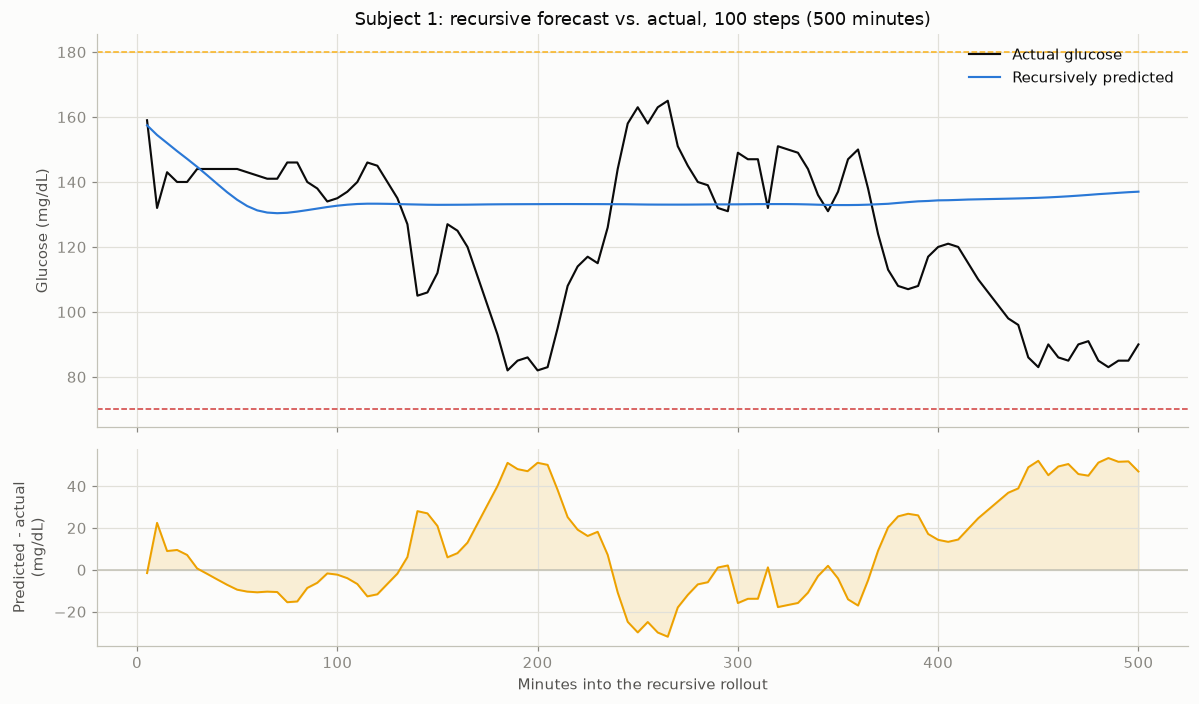

In [7]:
minutes_ahead = (trajectory["step"] + 1) * 5
error = trajectory["pred_CGM"] - trajectory["actual_CGM"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, height_ratios=[2, 1])

ax1.plot(minutes_ahead, trajectory["actual_CGM"], color=plotting.INK_PRIMARY, linewidth=1.4, label="Actual glucose")
ax1.plot(minutes_ahead, trajectory["pred_CGM"], color=plotting.CATEGORICAL[0], linewidth=1.4, label="Recursively predicted")
ax1.axhline(ref.HYPO_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hypo"], linewidth=1)
ax1.axhline(ref.HYPER_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hyper"], linewidth=1)
ax1.set_ylabel("Glucose (mg/dL)")
ax1.set_title(f"Subject {SUBJECT_ID}: recursive forecast vs. actual, {N_STEPS} steps ({N_STEPS*5} minutes)")
ax1.legend(frameon=False)

ax2.axhline(0, color=plotting.BASELINE, linewidth=1)
ax2.plot(minutes_ahead, error, color=plotting.CATEGORICAL[3], linewidth=1.3)
ax2.fill_between(minutes_ahead, error, 0, color=plotting.CATEGORICAL[3], alpha=0.15)
ax2.set_ylabel("Predicted - actual\n(mg/dL)")
ax2.set_xlabel("Minutes into the recursive rollout")

fig.tight_layout()
plt.show()

In [8]:
print(f"Mean absolute error, first 30 minutes:   {error[minutes_ahead <= 30].abs().mean():.1f} mg/dL")
print(f"Mean absolute error, last 30 minutes:     {error[minutes_ahead >= minutes_ahead.max() - 30].abs().mean():.1f} mg/dL")
print(f"Mean absolute error, whole rollout:       {error.abs().mean():.1f} mg/dL")
print(f"Max absolute error reached, and at what point:  {error.abs().max():.1f} mg/dL at minute {minutes_ahead[error.abs().idxmax()]}")

Mean absolute error, first 30 minutes:   8.4 mg/dL
Mean absolute error, last 30 minutes:     49.4 mg/dL
Mean absolute error, whole rollout:       20.7 mg/dL
Max absolute error reached, and at what point:  53.4 mg/dL at minute 485


## 5. What happened to the other three predictions

The recursive glucose curve above depends on what the model predicted for background insulin, meal insulin, and carbs at every step too, since those feed back in as input just like glucose does. Worth seeing directly, given the sparse-target concern raised at the start.

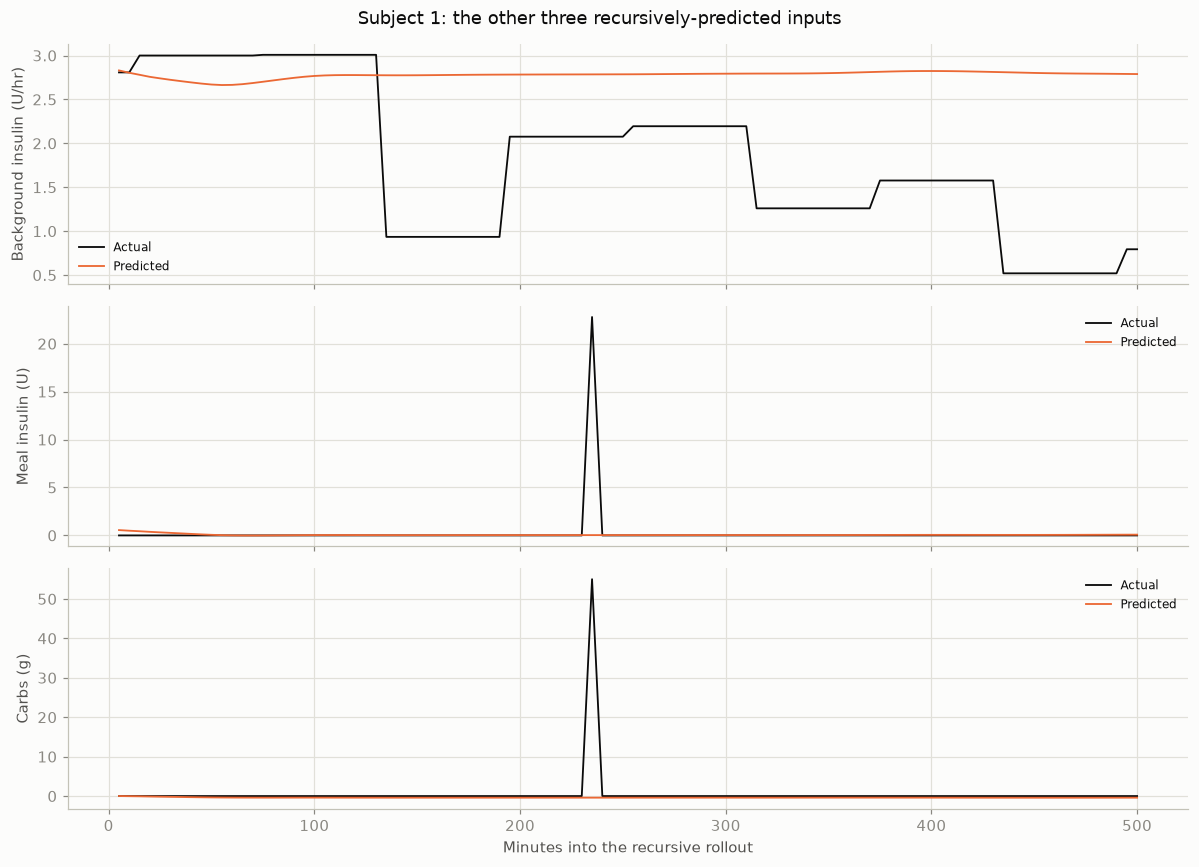

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
panels = [
    ("Basal", "Background insulin (U/hr)"),
    ("TotalBolusInsulinDelivered", "Meal insulin (U)"),
    ("CarbSize", "Carbs (g)"),
]
for ax, (col, ylabel) in zip(axes, panels):
    ax.plot(minutes_ahead, trajectory[f"actual_{col}"], color=plotting.INK_PRIMARY, linewidth=1.2, label="Actual")
    ax.plot(minutes_ahead, trajectory[f"pred_{col}"], color=plotting.CATEGORICAL[1], linewidth=1.2, label="Predicted")
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False, fontsize=8)
axes[-1].set_xlabel("Minutes into the recursive rollout")
fig.suptitle(f"Subject {SUBJECT_ID}: the other three recursively-predicted inputs")
fig.tight_layout()
plt.show()

## 6. What this shows

The single-step model itself is genuinely good: 10.2 mg/dL RMSE predicting glucose one 5-minute step ahead, against a 38.0 mg/dL baseline for just guessing the average. That part works.

The recursive rollout is a different story. Average error is 8.4 mg/dL over the first 30 minutes, still close to the one-step accuracy, but by the last 30 minutes of the 500-minute rollout it has grown to 49.4 mg/dL, almost 6 times worse, peaking at 53.4 mg/dL. Error does not creep up steadily. It tracks specific moments the model gets structurally wrong, not just accumulated small drift.

**The direct cause is visible in the other three predicted values.** Background insulin, meal insulin, and carbs all feed back into the model as input at every step, exactly like glucose does. Background insulin's prediction stays roughly in the right neighborhood, since it changes slowly. Meal insulin and carbs do not: the real data has a sharp, single meal partway through the rollout (about 22 units of insulin and 54 grams of carbs around minute 230), and the recursive prediction never sees it coming. It stays essentially flat near zero for the entire 500 minutes. That matches what the per-target validation numbers already showed before the rollout even started: the model's error on meal insulin and carbs was no better than just guessing the average value every time, while its glucose error beat that same baseline by a wide margin. The model was never actually predicting meals. It was predicting the safe default of no meal, which is usually correct, right up until it is not.

Because no meal ever gets simulated, the recursive glucose curve has nothing to react to. It settles into a flat line around 130-140 mg/dL within about an hour and stays there for the rest of the rollout, missing every real swing along the way: a drop to 83, a rise to 165, a later drop to 85. The gap between the flat prediction and the real, swinging glucose trace is exactly where the growing error in the panel above comes from.

This is not really a finding about this particular model being weak. Its one-step glucose accuracy is solid. It is a finding about what recursive forecasting actually requires that one-shot forecasting does not: some way to anticipate discrete, behavior-driven events (a meal, a correction dose) before they happen, not just react to them once logged. Nothing in a few hours of recent glucose and insulin history reliably signals that a meal is about to happen in the next 5 minutes, so a plain regression model has no real basis for predicting one, and defaults to predicting the common case instead. Closing that gap would need a genuinely different kind of model, most likely one that treats meals and doses as events to detect or plan around rather than a continuous quantity to regress on, not just a bigger or better-tuned version of this one.